In [1]:
import os
import json
import functools
import collections
from absl import logging


import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset

import tensorflow as tf
import sonnet as snt
from meshgraphnets import common
from meshgraphnets.common import NodeType
from meshgraphnets import normalization

In [ ]:
########### Data Wrangling ##############

def _parse(proto, meta):
  """
  Parses a trajectory from tf.Example.
  
    Workflow:
  1. Build a dictionary describing each field, and its TFRecord data type.
  2. Read a raw example (proto) from the TFRecord file.
  3. Create an output container.
  4. For each field:
    a. Decode raw binary data into a Tensor
    b. Reshape according to metadata
    c. Expand static fields across timesteps, or reconstruct dynamic fields
    d. Store the processed tensor in the output dict

    Returns:
      A dictionary that maps each field name to a time-series tensor 
      with shape [trajectory_length, ...]
  """
  feature_lists = {k: tf.io.VarLenFeature(tf.string)
                   for k in meta['field_names']}
  features = tf.io.parse_single_example(proto, feature_lists)
  out = {}
  for key, field in meta['features'].items():
    data = tf.io.decode_raw(features[key].values, getattr(tf, field['dtype']))
    data = tf.reshape(data, field['shape'])
    if field['type'] == 'static':
      data = tf.tile(data, [meta['trajectory_length'], 1, 1])
    elif field['type'] == 'dynamic_varlen':
      length = tf.io.decode_raw(features['length_'+key].values, tf.int32)
      length = tf.reshape(length, [-1])
      data = tf.RaggedTensor.from_row_lengths(data, row_lengths=length)
    elif field['type'] != 'dynamic':
      raise ValueError('invalid data format')
    out[key] = data
  return out


def load_dataset(path, split):
  """
  Loads the dataset from disk and returns a tf.data pipeline.

  Workflow:
    1. Reads metadata from meta.json
    2. Loads TFRecord files for a given split (train/valid/test)
    3. Parses trajectories using the _parse() function
    4. Prefetches 1 sample so the next trajectory is prepared in
       background while the current one is being processed
       (overlaps CPU I/O with GPU compute)

       Meaning:
         - GPU trains on trajectory N
         - CPU loads trajectory N+1
  """
  with open(os.path.join(path, 'meta.json'), 'r') as fp:
    meta = json.loads(fp.read())
  ds = tf.data.TFRecordDataset(os.path.join(path, split+'.tfrecord'))
  ds = ds.map(functools.partial(_parse, meta=meta), num_parallel_calls=20)
  ds = ds.prefetch(1)
  return ds


def add_targets(ds, fields, add_history):
  """
  Adds supervised learning targets (future values) and optionally
  previous values (history) to each trajectory.

  Workflow:
    Given a trajectory of shape [T, ...], for each field:
      - `val[1:-1]` becomes the current value (time t)
      - `val[0:-2]` becomes the history value (time t-1) if enabled
      - `val[2:]`   becomes the target value (time t+1)

    This aligns data along time steps so the model learns to predict
    the next state from the current (and optionally previous) state.
  """
  def fn(trajectory):
    out = {}
    for key, val in trajectory.items():
      out[key] = val[1:-1]
      if key in fields:
        if add_history:
          out['prev|'+key] = val[0:-2]
        out['target|'+key] = val[2:]
    return out
  return ds.map(fn, num_parallel_calls=20)


def split_and_preprocess(ds, noise_field, noise_scale, noise_gamma):
  """Splits trajectories into frames and adds controlled training noise.

    Workflow:
      - Trajectories are flattened into individual frames.
      - Noise is sampled from a normal distribution (stddev=noise_scale) 
        and added to the specified `noise_field`.
      - Noise is applied only to non-boundary nodes (NodeType.NORMAL).
      - Targets for the noisy field are updated with a scaled version 
        of the noise: (1 - noise_gamma) * noise.
      - The dataset is shuffled, repeated indefinitely, and prefetched 
        for efficient training.

    Args:
        ds: A tf.data.Dataset containing trajectory data.
        noise_field: Name of the field to which noise is added.
        noise_scale: Standard deviation of the Gaussian noise.
        noise_gamma: Scaling factor for noise applied to the target.

    Returns:
        A tf.data.Dataset with frames containing noisy inputs and updated targets.
  """
  def add_noise(frame):
    noise = tf.random.normal(tf.shape(frame[noise_field]),
                             stddev=noise_scale, dtype=tf.float32)
    # don't apply noise to boundary nodes
    mask = tf.equal(frame['node_type'], NodeType.NORMAL)[:, 0]
    mask = tf.expand_dims(mask, axis=-1) # FIX ADDED 
    noise = tf.where(mask, noise, tf.zeros_like(noise))
    frame[noise_field] += noise
    frame['target|'+noise_field] += (1.0 - noise_gamma) * noise
    return frame

  ds = ds.flat_map(tf.data.Dataset.from_tensor_slices)
  ds = ds.map(add_noise, num_parallel_calls=20)
  ds = ds.shuffle(10000)
  ds = ds.repeat(None)
  return ds.prefetch(10)


def batch_dataset(ds, batch_size):
  """
  Batches input graph datasets into a single merged graph per batch.
  Note: we are batching trajectories not a single time step.

  Workflow:
    1. Read shape and data types of dataset fields.
    2. Use `window()` to group multiple frames together.
    3. Apply batch accumulation to merge nodes and connectivity.

  Helper functions:
    * renumber:
        Adjusts cell (edge) indices by adding previously-seen nodes so
        connectivity remains valid when graphs are concatenated.
    * batch_accumulate:
        Collects all fields in the batch window and concatenates them
        into one combined graph structure.

  Why:
    MeshGraphNets uses graph batches as a single large graph so GNN
    message passing runs efficiently on GPU, rather than looping over
    many small graphs.

  Returns:
    A dataset where each element is a merged graph containing all node
    features, cell connectivity, and metadata from the 'batch_size'
    window of frames.
  """
  shapes = ds.output_shapes
  types = ds.output_types
  def renumber(buffer, frame):
    """
    buffer -> running accumulation result (so far)
    frame -> one element from the dataset window (snapshot at one time step)
    """
    nodes, cells = buffer
    new_nodes, new_cells = frame
    return nodes + new_nodes, tf.concat([cells, new_cells+nodes], axis=0)

  def batch_accumulate(ds_window):
    out = {}
    for key, ds_val in ds_window.items():
      initial = tf.zeros((0, shapes[key][1]), dtype=types[key])
      if key == 'cells':
        # renumber node indices in cells
        num_nodes = ds_window['node_type'].map(lambda x: tf.shape(x)[0])
        cells = tf.data.Dataset.zip((num_nodes, ds_val))
        initial = (tf.constant(0, tf.int32), initial)
        _, out[key] = cells.reduce(initial, renumber)
      else:
        merge = lambda prev, cur: tf.concat([prev, cur], axis=0)
        out[key] = ds_val.reduce(initial, merge)
    return out

  if batch_size > 1:
    ds = ds.window(batch_size, drop_remainder=True)
    ds = ds.map(batch_accumulate, num_parallel_calls=20)
  return ds

In [3]:
########### Graph Network Development ##############

EdgeSet = collections.namedtuple('EdgeSet', ['name', 'features', 'senders',
                                             'receivers'])
MultiGraph = collections.namedtuple('Graph', ['node_features', 'edge_sets'])


class GraphNetBlock(snt.Module):
  """Multi-Edge Interaction Network with residual connections."""

  def __init__(self, model_fn, name='GraphNetBlock'):
    super(GraphNetBlock, self).__init__(name=name)
    self._model_fn = model_fn
    self._edge_mlp = self._model_fn()
    self._node_mlp = self._model_fn()

  def _update_edge_features(self, node_features, edge_set):
    """
    *Message construction*
    Updates features for each edge in the graph.

    Workflow:
      1. Gather sender node features from the global node features.
      2. Gather receiver node features from the global node features.
      3. Combine sender, receiver, and existing edge features into a single tensor.
      4. Apply the edge update function (MLP or model_fn) to compute new edge features.

    Returns:
      Tensor of updated edge features, with shape [num_edges, updated_feature_dim].
    """
    sender_features = tf.gather(node_features, edge_set.senders)
    receiver_features = tf.gather(node_features, edge_set.receivers)
    features = [sender_features, receiver_features, edge_set.features]
    return self._edge_mlp(tf.concat(features, axis=-1))

  def _update_node_features(self, node_features, edge_sets):
    """
    Updates node features by aggregating incoming edge information and applying a node function.

    Workflow:
      1. Start with the current node features.
      2. For each edge set:
         a. Aggregate incoming edge features for each node by summing the features
            of all edges that point to that node (using `unsorted_segment_sum`).
      3. Concatenate the original node features with the aggregated edge features.
      4. Apply the node update function (MLP or `model_fn`) to compute updated node features.

    Args:
      node_features: Tensor of shape [num_nodes, node_feature_dim], the current node features.
      edge_sets: List of edge sets, each containing `features` and `receivers`.

    Returns:
      Tensor of updated node features, with shape [num_nodes, updated_feature_dim].
    """
    num_nodes = tf.shape(node_features)[0]
    features = [node_features]
    for edge_set in edge_sets:
      features.append(tf.math.unsorted_segment_sum(edge_set.features,
                                                   edge_set.receivers,
                                                   num_nodes))
    return self._node_mlp(tf.concat(features, axis=-1))

  def __call__(self, graph):
    """Applies GraphNetBlock and returns updated MultiGraph."""

    # apply edge functions
    new_edge_sets = []
    for edge_set in graph.edge_sets:
      updated_features = self._update_edge_features(graph.node_features,
                                                    edge_set)
      new_edge_sets.append(edge_set._replace(features=updated_features))

    # apply node function
    new_node_features = self._update_node_features(graph.node_features,
                                                   new_edge_sets)

    # add residual connections
    new_node_features += graph.node_features
    new_edge_sets = [es._replace(features=es.features + old_es.features)
                     for es, old_es in zip(new_edge_sets, graph.edge_sets)]
    return MultiGraph(new_node_features, new_edge_sets)
  


class EncodeProcessDecode(snt.Module):
    """Encode-Process-Decode GraphNet model."""

    def __init__(
        self, output_size, latent_size, num_layers, message_passing_steps,
        name="EncodeProcessDecode"
    ):
        super().__init__(name=name)

        self._latent_size = latent_size
        self._output_size = output_size
        self._num_layers = num_layers
        self._message_passing_steps = message_passing_steps

        # Build encoder MLPs
        self.node_encoder = self._make_mlp(latent_size)
        self.edge_encoder = self._make_mlp(latent_size)

        # Build message passing blocks (each with its own parameters)
        self.blocks = [
            GraphNetBlock(lambda: self._make_mlp(latent_size))
            for _ in range(message_passing_steps)
        ]

        # Build decoder
        self.decoder = self._make_mlp(output_size, layer_norm=False)

    def _make_mlp(self, output_size, layer_norm=True):
        widths = [self._latent_size] * self._num_layers + [output_size]
        core = snt.nets.MLP(widths, activate_final=False)

        if layer_norm:
            return snt.Sequential([
                core,
                snt.LayerNorm(axis=-1, create_scale=True, create_offset=True)
            ])
        else:
            return core

    def _encoder(self, graph):
        node_latents = self.node_encoder(graph.node_features)

        new_edges = []
        for e in graph.edge_sets:
            new_edges.append(
                e._replace(features=self.edge_encoder(e.features))
            )

        return MultiGraph(node_latents, new_edges)

    def __call__(self, graph):
        latent_graph = self._encoder(graph)

        # Apply message passing blocks (with shared, persistent parameters)
        for block in self.blocks:
            latent_graph = block(latent_graph)

        return self.decoder(latent_graph.node_features)


In [4]:
############# Graph Creation ##############

class Model(snt.Module):
  """Model for fluid simulation."""

  def __init__(self, learned_model, name='Model'):
    super(Model, self).__init__(name=name)
    self._learned_model = learned_model
    self._output_normalizer = normalization.Normalizer(
        size=2, name='output_normalizer')
    self._node_normalizer = normalization.Normalizer(
        size=2+common.NodeType.SIZE, name='node_normalizer')
    self._edge_normalizer = normalization.Normalizer(
        size=3, name='edge_normalizer')  # 2D coord + length

  def _build_graph(self, inputs, is_training):
    """Builds input graph."""
    # construct graph nodes
    node_type = tf.one_hot(inputs['node_type'][:, 0], common.NodeType.SIZE)
    node_features = tf.concat([inputs['velocity'], node_type], axis=-1)

    # construct graph edges
    senders, receivers = common.triangles_to_edges(inputs['cells'])
    relative_mesh_pos = (tf.gather(inputs['mesh_pos'], senders) -
                         tf.gather(inputs['mesh_pos'], receivers))
    edge_features = tf.concat([
        relative_mesh_pos,
        tf.norm(relative_mesh_pos, axis=-1, keepdims=True)], axis=-1)

    mesh_edges = EdgeSet(
        name='mesh_edges',
        features=self._edge_normalizer(edge_features, is_training),
        receivers=receivers,
        senders=senders)
    return MultiGraph(
        node_features=self._node_normalizer(node_features, is_training),
        edge_sets=[mesh_edges])

  def __call__(self, inputs):
    graph = self._build_graph(inputs, is_training=False)
    per_node_network_output = self._learned_model(graph)
    return self._update(inputs, per_node_network_output)


  def loss(self, inputs):
    """L2 loss on velocity."""
    graph = self._build_graph(inputs, is_training=True)
    network_output = self._learned_model(graph)

    # build target velocity change
    cur_velocity = inputs['velocity']
    target_velocity = inputs['target|velocity']
    target_velocity_change = target_velocity - cur_velocity
    target_normalized = self._output_normalizer(target_velocity_change, accumulate=False)

    # build loss
    node_type = inputs['node_type'][:, 0]
    loss_mask = tf.logical_or(tf.equal(node_type, common.NodeType.NORMAL),
                              tf.equal(node_type, common.NodeType.OUTFLOW))
    error = tf.reduce_sum((target_normalized - network_output)**2, axis=1)
    loss = tf.reduce_mean(error[loss_mask])
    return loss

  def _update(self, inputs, per_node_network_output):
    """Integrate model outputs."""
    velocity_update = self._output_normalizer.inverse(per_node_network_output)
    # integrate forward
    cur_velocity = inputs['velocity']
    return cur_velocity + velocity_update

In [5]:
######################## Model Evaluation #############################
def _rollout(model, initial_state, num_steps):
  """Rolls out a model trajectory."""
  node_type = initial_state['node_type'][:, 0]
  mask = tf.logical_or(tf.equal(node_type, NodeType.NORMAL),
                       tf.equal(node_type, NodeType.OUTFLOW))

  def step_fn(step, velocity, trajectory):
    prediction = model({**initial_state,
                        'velocity': velocity})
    # don't update boundary nodes
    next_velocity = tf.where(mask, prediction, velocity)
    trajectory = trajectory.write(step, velocity)
    return step+1, next_velocity, trajectory

  _, _, output = tf.while_loop(
      cond=lambda step, cur, traj: tf.less(step, num_steps),
      body=step_fn,
      loop_vars=(0, initial_state['velocity'],
                 tf.TensorArray(tf.float32, num_steps)),
      parallel_iterations=1)
  return output.stack()


def evaluate(model, inputs):
  """Performs model rollouts and create stats."""
  initial_state = {k: v[0] for k, v in inputs.items()}
  num_steps = inputs['cells'].shape[0]
  prediction = _rollout(model, initial_state, num_steps)

  error = tf.reduce_mean((prediction - inputs['velocity'])**2, axis=-1)
  scalars = {'mse_%d_steps' % horizon: tf.reduce_mean(error[1:horizon+1])
             for horizon in [1, 10, 20, 50, 100, 200]}
  traj_ops = {
      'faces': inputs['cells'],
      'mesh_pos': inputs['mesh_pos'],
      'gt_velocity': inputs['velocity'],
      'pred_velocity': prediction
  }
  return scalars, traj_ops

## Graph Sample Construction and Visualization

In [6]:
# varaibles
dataset_dir = "data/cylinder_flow/"
checkpoint_dir = "data/cylinder_flow/checkpoint/"
rollout_dir= "data/cylinder_flow/rollout.pkl"
params = dict(noise=0.02, gamma=1.0, field='velocity', history=False,
                size=2, batch=2, model="cfd_model", evaluator="cfd_eval")

num_training_steps = int(10e6)

In [7]:
# Load the dataset (TFRecord parser, targets, noise, etc.)
ds = load_dataset(dataset_dir, 'valid')
ds = add_targets(ds, [params['field']], add_history=params['history'])
ds = split_and_preprocess(ds,
                                  noise_field=params['field'],
                                  noise_scale=params['noise'],
                                  noise_gamma=params['gamma'])

# Take one batch for visualization
inputs = next(iter(ds.take(1)))

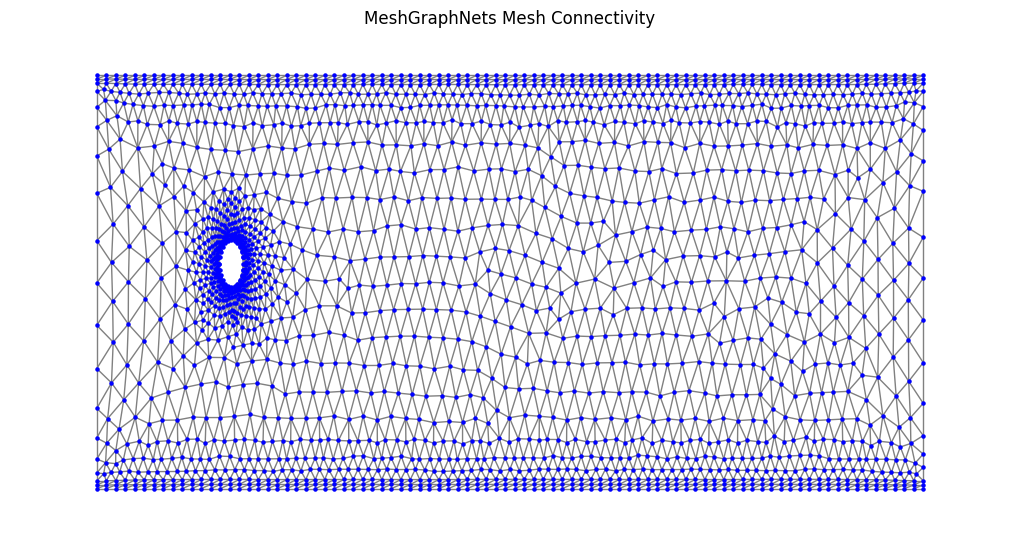

In [9]:
# Extract fields
cells = inputs["cells"].numpy()
mesh_pos = inputs["mesh_pos"].numpy()

# Create an undirected graph
G = nx.Graph()

# Add nodes with coordinates
for i, (x, y) in enumerate(mesh_pos):
    G.add_node(i, pos=(x, y))

# Add edges from triangular cells
for tri in cells:
    a, b, c = tri
    G.add_edge(a, b)
    G.add_edge(b, c)
    G.add_edge(c, a)

# Draw graph
pos = nx.get_node_attributes(G, 'pos')
plt.figure(figsize=(10, 5))
nx.draw(
    G, pos,
    node_size=5,
    edge_color="gray",
    node_color="blue"
)
plt.title("MeshGraphNets Mesh Connectivity")
plt.show()


## GNN Training

In [10]:

################################# Model Training #################################
learned_model = EncodeProcessDecode(
      output_size=params['size'],
      latent_size=128,
      num_layers=2,
      message_passing_steps=15)

model = Model(learned_model)

# Load and preprocess dataset
ds = load_dataset(dataset_dir, 'train')
ds = add_targets(ds, [params['field']], add_history=params['history'])
ds = split_and_preprocess(ds, noise_field=params['field'],
                                noise_scale=params['noise'],
                                noise_gamma=params['gamma'])


# Convert only float inputs; cast indices separately
def convert_inputs(inputs):
    inputs = {k: v if v.dtype.is_floating else tf.cast(v, tf.int32)
              for k, v in inputs.items()}
    # Ensure float tensors are float32
    inputs = {k: tf.cast(v, tf.float32) if v.dtype.is_floating else v
              for k, v in inputs.items()}
    return inputs

ds = ds.map(convert_inputs)
ds = ds.prefetch(20)

# Global step and optimizer
global_step = tf.Variable(0, trainable=False, dtype=tf.int64)

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-4,
    decay_steps=int(5e6),
    decay_rate=0.1,
    staircase=False
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Compile the training step for GPU efficiency
@tf.function
def train_step(inputs):
    with tf.GradientTape() as tape:
        loss = model.loss(inputs)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    global_step.assign_add(1)
    return loss

# Training loop
for step, inputs in enumerate(ds):
    # Warm-up: accumulate normalization stats for first 1000 steps
    if global_step < 1000:
        global_step.assign_add(1)
        continue

    loss_value = train_step(inputs)

    if int(global_step) % 1000 == 0:
        print(f"Step {int(global_step)}: Loss = {loss_value.numpy()}")

    if int(global_step) >= num_training_steps:
        break

print("Training complete.")

Step 2000: Loss = 8068802281472.0
Step 3000: Loss = 6791981694976.0
Step 4000: Loss = 5300976353280.0
Step 5000: Loss = 7073353957376.0


KeyboardInterrupt: 

In [26]:

################################# Model Training #################################
learned_model = EncodeProcessDecode(
      output_size=params['size'],
      latent_size=128,
      num_layers=2,
      message_passing_steps=15)

model = Model(learned_model)

# Load and preprocess dataset
ds = load_dataset(dataset_dir, 'train')
ds = add_targets(ds, [params['field']], add_history=params['history'])
ds = split_and_preprocess(ds, noise_field=params['field'],
                                noise_scale=params['noise'],
                                noise_gamma=params['gamma'])

iterator = iter(ds) # Update
inputs = next(iterator) # Update

global_step = tf.Variable(0, trainable=False, dtype=tf.int64)

lr = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-4,
    decay_steps=int(5e6),
    decay_rate=0.1,
    staircase=False
                )
optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

# Compile the training step for GPU efficiency
@tf.function
def train_step(inputs):
    with tf.GradientTape() as tape:
        loss = model.loss(inputs)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    global_step.assign_add(1)
    return loss


# Training loop
for step, inputs in enumerate(ds):  # ds is your preprocessed dataset
    # Warm-up: accumulate normalization stats for first 1000 steps
    if global_step < 1000:
        global_step.assign_add(1)
        continue

    loss = train_step(inputs)

    if int(global_step) % 1000 == 0:
        print(f"Step {int(global_step)}: Loss = {loss.numpy()}")
    
    if int(global_step) >= num_training_steps:
        break

print("Training complete.")

ValueError: in user code:

    File "C:\Users\emman\AppData\Local\Temp\ipykernel_86780\1379784947.py", line 34, in train_step  *
        loss = model.loss(inputs)
    File "c:\Users\emman\anaconda3\envs\ml_env\lib\site-packages\sonnet\src\utils.py", line 85, in _decorate_unbound_method  *
        return decorator_fn(bound_method, self, args, kwargs)
    File "c:\Users\emman\anaconda3\envs\ml_env\lib\site-packages\sonnet\src\base.py", line 262, in wrap_with_name_scope  *
        return method(*args, **kwargs)
    File "C:\Users\emman\AppData\Local\Temp\ipykernel_86780\882896258.py", line 47, in loss  *
        graph = self._build_graph(inputs, is_training=True)
    File "c:\Users\emman\anaconda3\envs\ml_env\lib\site-packages\sonnet\src\utils.py", line 85, in _decorate_unbound_method  *
        return decorator_fn(bound_method, self, args, kwargs)
    File "c:\Users\emman\anaconda3\envs\ml_env\lib\site-packages\sonnet\src\base.py", line 262, in wrap_with_name_scope  *
        return meth